In [2]:
import warnings
warnings.filterwarnings("ignore")

import copy 
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [4]:
data=pd.read_csv("Titanic-Dataset.csv")

In [5]:
data.head(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
data.Cabin.value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [10]:
columns = [col for col in data.columns]

for col in columns:
    print("\n",data[col].value_counts(),"\n")


 PassengerId
891    1
1      1
2      1
3      1
4      1
      ..
16     1
15     1
14     1
13     1
12     1
Name: count, Length: 891, dtype: int64 


 Survived
0    549
1    342
Name: count, dtype: int64 


 Pclass
3    491
1    216
2    184
Name: count, dtype: int64 


 Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64 


 Sex
male      577
female    314
Name: count, dty

In [11]:
columns = [col for col in data.columns if data[col].dtype == 'object']

for col in columns:
    print("\n",data[col].value_counts(),"\n")


 Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64 


 Sex
male      577
female    314
Name: count, dtype: int64 


 Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
373450              1
STON/O2. 3101282    1
Name: count,

In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
columns = [col for col in data.columns if data[col].dtype != 'object']

for col in columns:
    print("\n",col,data[col].skew().sum(),"\n")



 PassengerId 0.0 


 Survived 0.4785234382949897 


 Pclass -0.6305479068752845 


 Age 0.38910778230082704 


 SibSp 3.6953517271630565 


 Parch 2.7491170471010933 


 Fare 4.787316519674893 



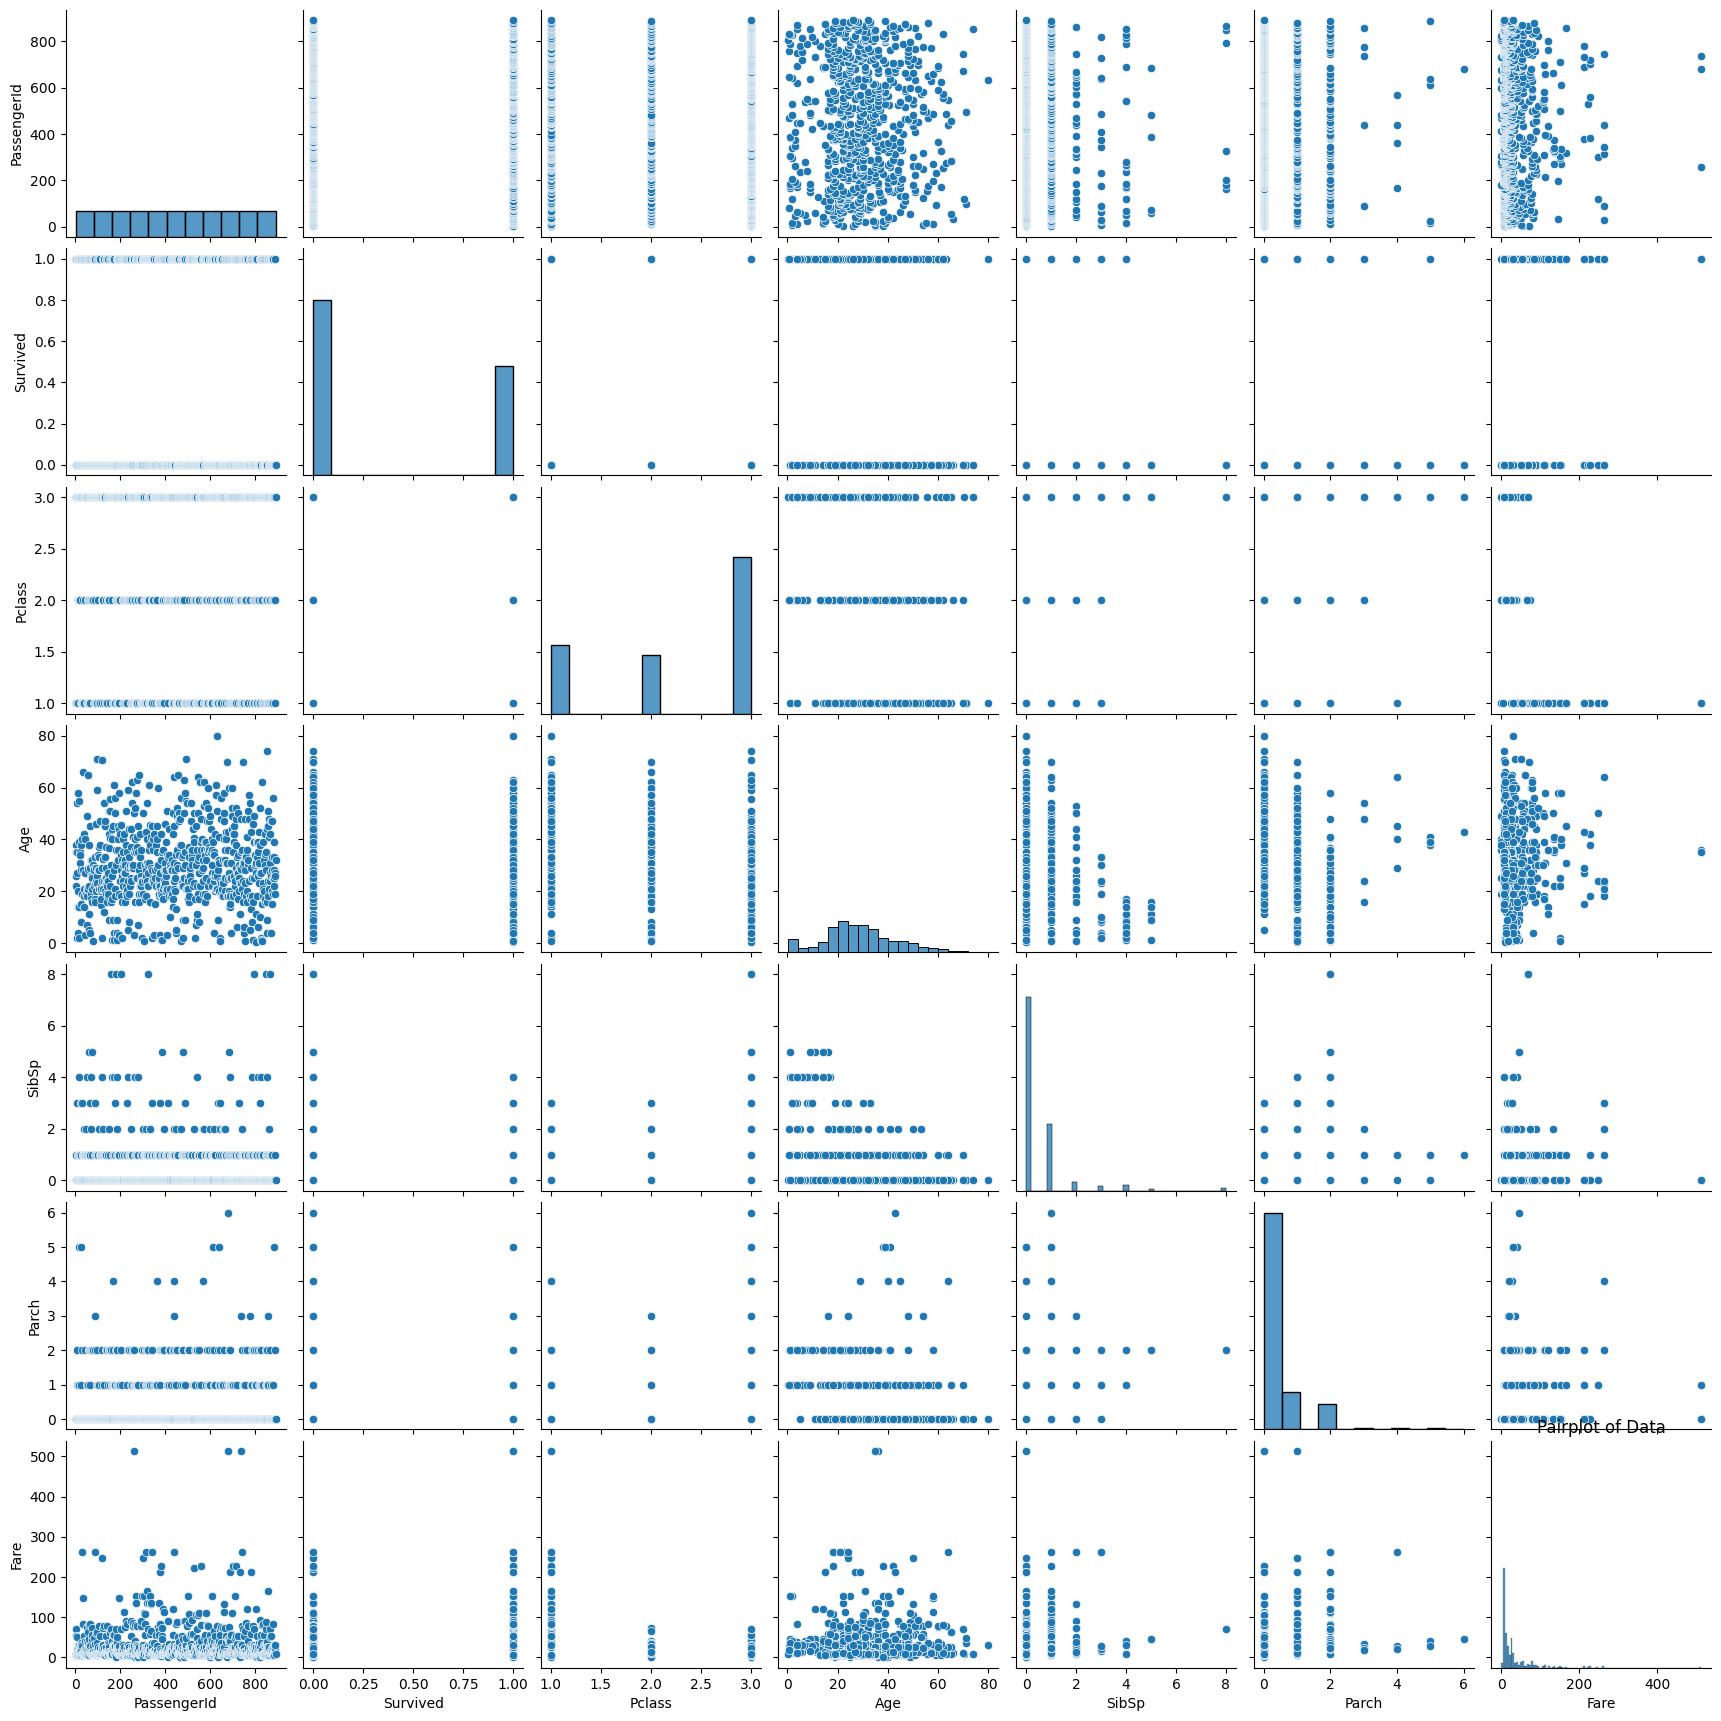

In [14]:
sns.pairplot(data)
plt.title('Pairplot of Data')
plt.show()

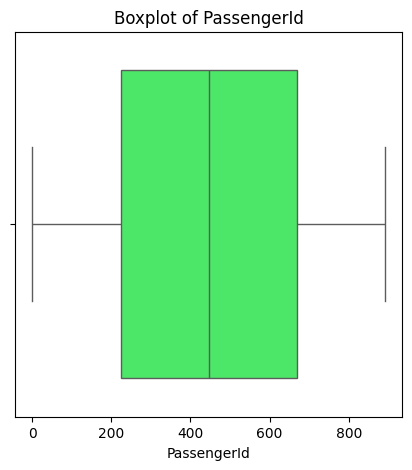

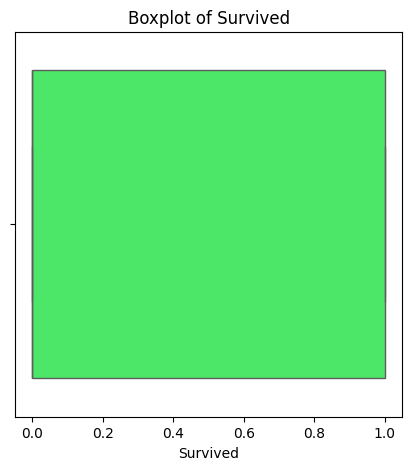

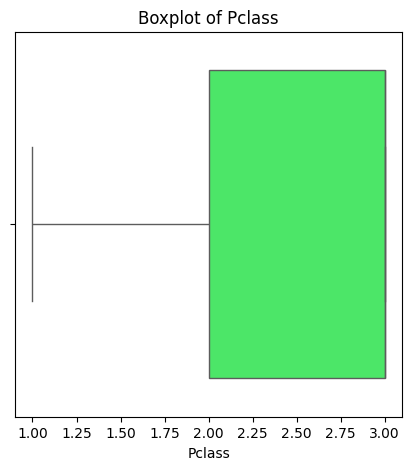

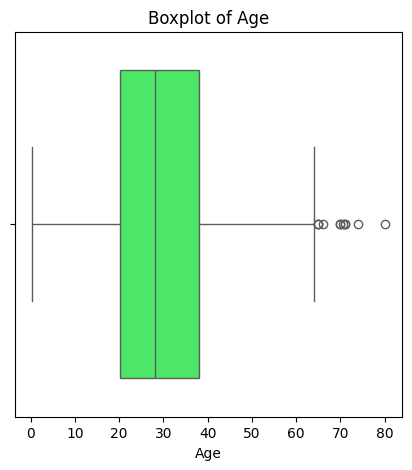

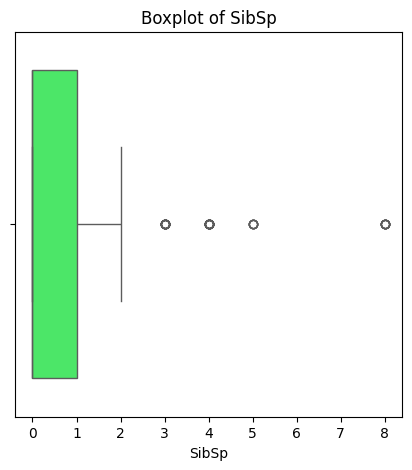

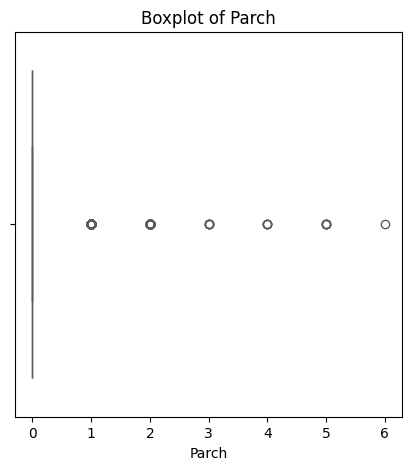

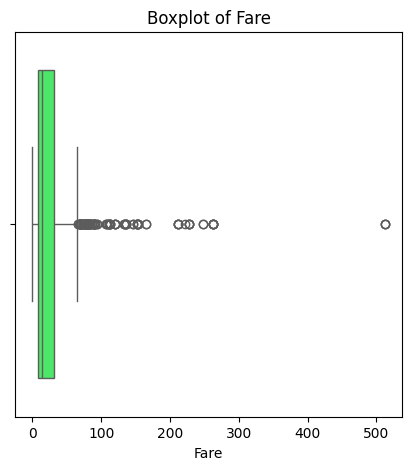

In [15]:
custom_palette = ["#33FF57"]

# To show the outliers of each column
for col in data.select_dtypes(include=['int', 'float']).columns:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_title(f'Boxplot of {col}')
    bp = sns.boxplot(data=data, x=col, ax=ax, palette=custom_palette)
    plt.show()
    plt.close(fig)

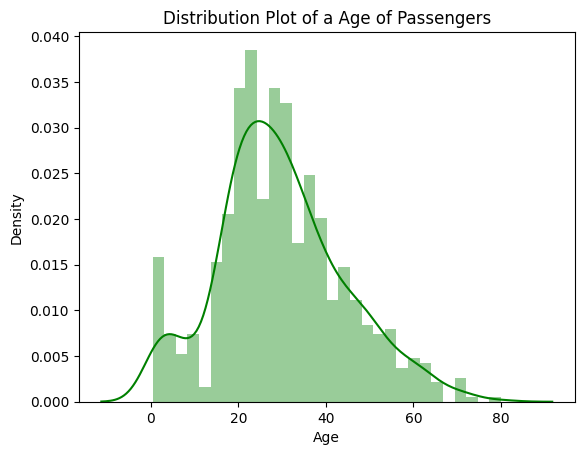

In [16]:
sns.distplot(data['Age'], kde=True, bins=30, color='green')
plt.title('Distribution Plot of a Age of Passengers')
plt.show()


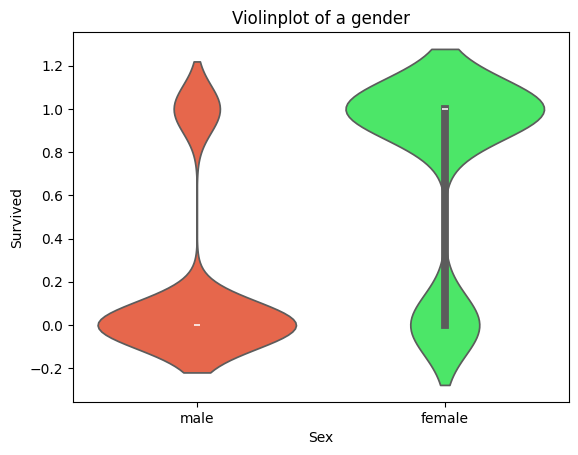

In [17]:
custom_palette = ["#FF5733", "#33FF57"]
sns.violinplot(x='Sex', y='Survived', data=data,palette=custom_palette)
plt.title('Violinplot of a gender')
plt.show()

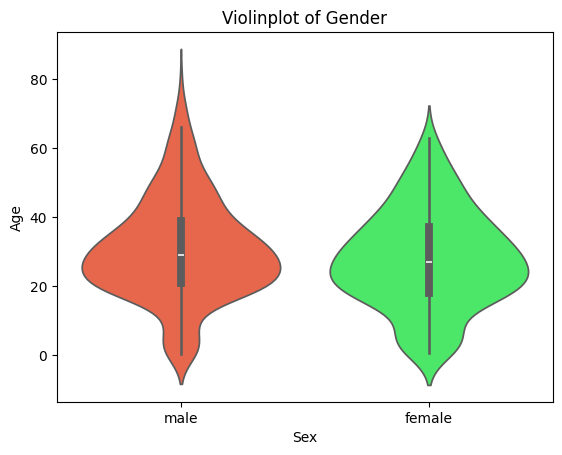

In [18]:
custom_palette = ["#FF5733", "#33FF57"]
sns.violinplot(x='Sex', y='Age', data=data, palette=custom_palette)
plt.title('Violinplot of Gender')
plt.show()

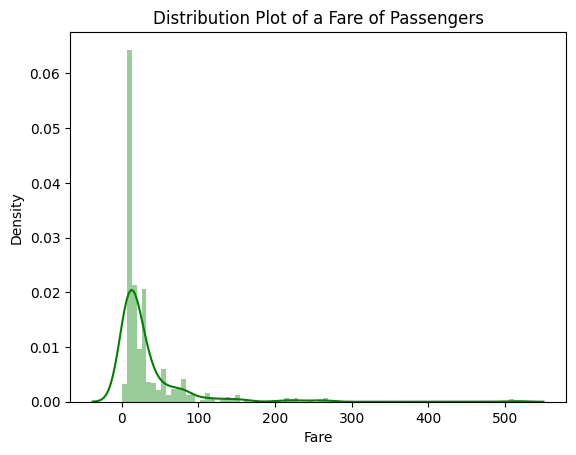

In [19]:
sns.distplot(data['Fare'], kde=True, bins=80, color='green')
plt.title('Distribution Plot of a Fare of Passengers')
plt.show()

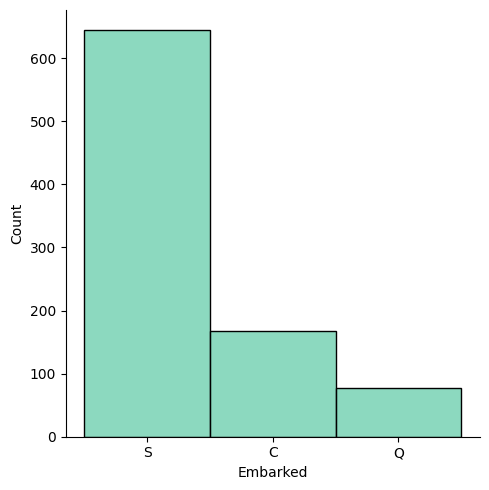

In [20]:
custom_palette = [ "#66CDAA"]  
sns.set_palette(custom_palette)
sns.displot(data=data, x="Embarked")


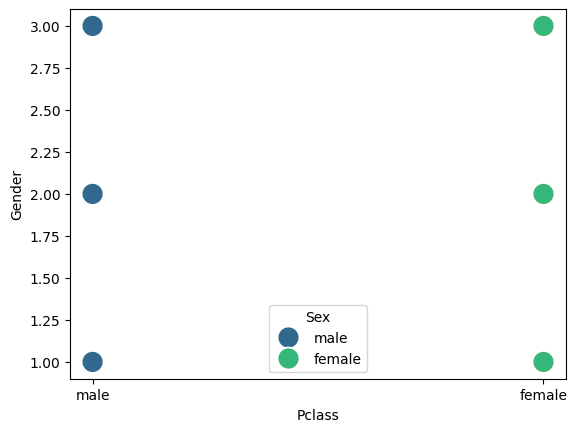

In [21]:
sns.scatterplot(data=data, x="Sex",y="Pclass", hue="Sex", palette="viridis",s=250)
plt.xlabel('Pclass')
plt.ylabel('Gender')
plt.show()


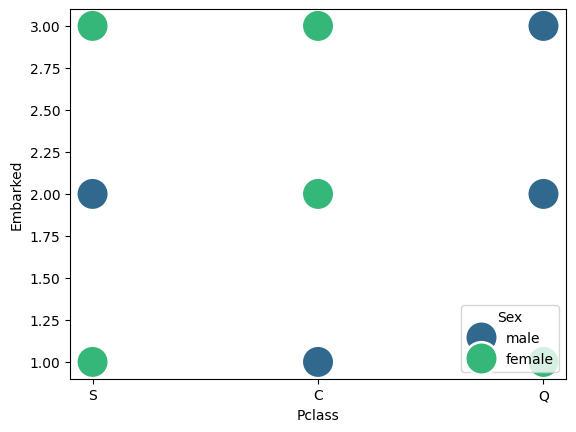

In [22]:
sns.scatterplot(data=data, x="Embarked",y="Pclass", hue="Sex", palette="viridis",s=550)
plt.xlabel('Pclass')
plt.ylabel('Embarked')
plt.show()